# Superfermion Clifford Circuits at 1000+ Qubits

The stabilizer tableau (Aaronson-Gottesman) evolves Clifford circuits with **O(n)**
work per gate and **no exponential state** - the only representation that reaches
1000+ qubits on a laptop. This notebook pushes the committed build to its documented
**1024-qubit tableau cap** and validates correctness at every scale.

**Methodology**

- Seeded random Clifford brickwork (H / S / CX), built once outside the timed region.
- Engines: Superfermion `method='stabilizer'` (Rust tableau) and Qiskit Aer
  `method='stabilizer'` (C++), same circuits, same shot counts.
- Aer rows stop at n=256: Aer's stabilizer grows super-linearly on this host
  (measured below and in `benchmark_master.ipynb`: 52 s/call at n=500), while SF
  stays sub-second to n=1024. The omission is disclosed in every table.
- Correctness at scale: TVD gate at n=10, exact tableau expectation values vs
  empirical sample means at n=512, GHZ(1024) structure, and the documented
  1024-qubit cap behavior at n=2048.
- Timing: per-size warmup + medians; trial counts stated per section; raw trials
  go to the JSON. Throughput is reported as qubit-gates/second.

In [1]:
# -- Bootstrap: pin the fixed LOCAL build (added 2026-09-24) ----------------
# Numbers in this notebook must describe the fixed local build, not any
# globally installed wheel, so the repo is pinned ahead of site-packages.
import sys as _sys
import hashlib as _hashlib
from pathlib import Path as _Path
REPO = _Path(r"C:\Users\ASUS\OneDrive\Desktop\sfdocs\superfermion")
assert (REPO / 'superfermion' / '__init__.py').exists(), f'repo not found: {REPO}'
if str(REPO) not in _sys.path:
    _sys.path.insert(0, str(REPO))
import superfermion._sf_core as _sfcore
_core = _Path(_sfcore.__file__)
print('=' * 78)
print('ENGINE PROVENANCE - fixed local build pinned for this run')
print('=' * 78)
print(f'  engine : {_core.name}  md5 {_hashlib.md5(_core.read_bytes()).hexdigest().upper()}')
print()

import gc
import time
import json
import platform
import numpy as np
from statistics import median

import superfermion as sf
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

print(f"Python: {platform.python_version()}")
print(f"CPU: {platform.processor() or 'unknown'}")
print(f"OS: {platform.system()} {platform.release()}")
print(f"SF version: {sf.__version__}")

ENGINE PROVENANCE - fixed local build pinned for this run
  engine : _sf_core.cp313-win_amd64.pyd  md5 17B755C032D01D0C9711EA2B75751506



Python: 3.13.3
CPU: Intel64 Family 6 Model 142 Stepping 12, GenuineIntel
OS: Windows 11
SF version: 0.1.12


In [2]:
# ── helpers ───────────────────────────────────────────────────────────────────
def timed(fn):
    gc.disable()
    t0 = time.perf_counter()
    result = fn()
    elapsed = (time.perf_counter() - t0) * 1000
    gc.enable()
    return result, elapsed

def benchmark(fn, n_trials):
    times = []
    for _ in range(n_trials):
        _, t = timed(fn)
        times.append(round(t, 2))
    med = median(times)
    s = sorted(times)
    q1 = s[len(s)//4]
    q3 = s[3*len(s)//4]
    return med, times, q1, q3

def fmt(sf_ms, qk_ms):
    if sf_ms < qk_ms:
        return f'SF {qk_ms/sf_ms:.1f}x faster'
    return f'Aer {sf_ms/qk_ms:.2f}x faster'

def build_brickwork(n, depth, seed=11):
    'Seeded Clifford brickwork: H all, CX even, S (seeded), CX odd, per layer.'
    rng = np.random.default_rng(seed)
    sc = sf.Circuit(n); qc = QuantumCircuit(n)
    for _ in range(depth):
        for q in range(n):
            sc.h(q); qc.h(q)
        for q in range(0, n - 1, 2):
            sc.cx(q, q + 1); qc.cx(q, q + 1)
        s_flags = rng.integers(0, 2, size=n)
        for q in range(n):
            if s_flags[q]:
                sc.s(q); qc.s(q)
        for q in range(1, n - 1, 2):
            sc.cx(q, q + 1); qc.cx(q, q + 1)
    return sc, qc

def build_clifford_only(n):
    'The benchmark_master.ipynb Clifford circuit (fixed brickwork, ~6 layers).'
    sc = sf.Circuit(n); qc = QuantumCircuit(n)
    for q in range(n):         sc.h(q);  qc.h(q)
    for q in range(0, n-1, 2): sc.cx(q, q+1); qc.cx(q, q+1)
    for q in range(n):         sc.s(q);  qc.s(q)
    for q in range(1, n-1, 2): sc.cx(q, q+1); qc.cx(q, q+1)
    for q in range(n):         sc.h(q);  qc.h(q)
    for q in range(0, n-1, 2): sc.cx(q, q+1); qc.cx(q, q+1)
    return sc, qc

def build_ghz(n):
    sc = sf.Circuit(n); qc = QuantumCircuit(n)
    sc.h(0); qc.h(0)
    for i in range(1, n): sc.cx(0, i); qc.cx(0, i)
    return sc, qc

def exact_probs(sc, n):
    sv = np.array(sf.run(sc, device='cpu', shots=0).statevector)
    return {format(i, f'0{n}b'): float(p)
            for i, p in enumerate(np.abs(sv) ** 2) if p > 1e-15}

def tvd_vs_exact(cnt, probs, shots):
    keys = set(cnt) | set(probs)
    dist = 0.5 * sum(abs(cnt.get(k, 0) / shots - probs.get(k, 0.0)) for k in keys)
    expected = np.sqrt(len(probs) / (2 * np.pi * shots))
    return dist, expected, 4 * expected

def z_string_pauli(n, qubits):
    paulis = [0] * n
    for q in qubits:
        paulis[q] = 3
    return [(paulis, 1.0, 0.0)]

print('Helpers defined.')

Helpers defined.


## 1. Correctness at scale

Three independent checks:

1. **TVD gate (n=10)**: 200k stabilizer samples vs the exact statevector distribution,
   4-sigma threshold (same gate as `benchmark_master.ipynb`).
2. **Exact tableau vs samples (n=512)**: for 12 random qubits, the exact tableau
   expectation `<Z_q>` (O(n^2) symplectic computation) must match the empirical
   sample mean within 4-sigma of binomial sampling noise.
3. **GHZ(1024)**: exactly two outcomes, ~50/50.

In [3]:
print('=' * 88)
print('CORRECTNESS AT SCALE')
print('=' * 88)
correctness = {}

# 1) TVD gate at n=10
sc10, _ = build_clifford_only(10)
probs10 = exact_probs(sc10, 10)
shots_check = 200000
cnt10 = sf.run(sc10, device='cpu', method='stabilizer', shots=shots_check, seed=42).counts
dist, expected, thr = tvd_vs_exact(cnt10, probs10, shots_check)
correctness['tvd_n10'] = {'tvd': dist, 'expected': float(expected), 'threshold': float(thr)}
print(f'1) TVD n=10: {dist:.4f} (expected~{expected:.4f}, thr={thr:.4f}) '
      f'| {"PASS" if dist < thr else "FAIL"}')
assert dist < thr

# 2) exact tableau expval vs sample means at n=512
n_512 = 512
sc512, _ = build_brickwork(n_512, depth=6, seed=5)
st512 = sf.run(sc512, device='cpu', method='stabilizer', shots=0)
shots_v = 50000
cnt512 = sf.run(sc512, device='cpu', method='stabilizer', shots=shots_v, seed=3).counts
rng = np.random.default_rng(0)
check_qubits = sorted(rng.choice(n_512, size=12, replace=False).tolist())
max_sig = 0.0
print(f'\n2) n={n_512}: exact tableau <Z_q> vs sample mean (50k shots):')
for q in check_qubits:
    exact_val = st512.state.expectation(z_string_pauli(n_512, [q]))
    ones = sum(c for k, c in cnt512.items() if (int(k, 2) >> q) & 1)
    emp = 1 - 2 * ones / shots_v
    sigma = np.sqrt((1 - exact_val ** 2) / shots_v)
    nsig = abs(emp - exact_val) / sigma if sigma > 0 else 0.0
    max_sig = max(max_sig, nsig)
    if q in check_qubits[:4]:
        print(f'   q={q:3d}: exact={exact_val:+.4f} sample={emp:+.4f} ({nsig:.1f} sigma)')
print(f'   max deviation over 12 qubits: {max_sig:.2f} sigma (gate: < 4)')
correctness['n512_max_sigma'] = float(max_sig)
assert max_sig < 4, 'sample means deviate from exact tableau values'

# 3) GHZ(1024)
scg, _ = build_ghz(1024)
cntg = sf.run(scg, device='cpu', method='stabilizer', shots=10000, seed=7).counts
vals = sorted(cntg.values())
Ng = sum(vals)
print(f'\n3) GHZ(1024): {len(cntg)} outcomes {vals} | dev from N/2 = {abs(vals[0]-Ng/2):.0f} (5sig={5*np.sqrt(Ng*0.25):.0f})')
assert len(cntg) == 2 and all(abs(v - Ng/2) < 5 * np.sqrt(Ng*0.25) for v in vals)
correctness['ghz1024'] = {'counts': vals}
print('\nAll correctness checks passed.')

CORRECTNESS AT SCALE
1) TVD n=10: 0.0281 (expected~0.0285, thr=0.1142) | PASS



2) n=512: exact tableau <Z_q> vs sample mean (50k shots):
   q=  8: exact=+0.0000 sample=-0.0030 (0.7 sigma)
   q= 20: exact=+1.0000 sample=+1.0000 (0.0 sigma)


   q= 38: exact=+0.0000 sample=+0.0001 (0.0 sigma)
   q= 89: exact=+0.0000 sample=-0.0052 (1.2 sigma)


   max deviation over 12 qubits: 2.16 sigma (gate: < 4)

3) GHZ(1024): 2 outcomes [4962, 5038] | dev from N/2 = 38 (5sig=250)

All correctness checks passed.


## 2. Scaling ladder (depth-8 brickwork, 10k shots)

SF: 32 -> 1024 qubits (5-10 trials). Aer: 32 -> 256 only, 3 trials - the omission
beyond 256 is driven by Aer's measured growth (52 s/call at n=500,
`benchmark_master.ipynb`, same build).

In [4]:
ladder_sf = [(32, 10), (64, 10), (128, 7), (256, 7), (512, 5), (1024, 5)]
ladder_aer = [(32, 3), (64, 3), (128, 3), (256, 3)]
cliff_results = {}

print('=' * 104)
print('CLIFFORD SCALING LADDER (depth-8 brickwork, shots=10000)')
print('=' * 104)
print(f'{"n":>5s} {"gates":>7s} {"trials":>6s} | {"SF med":>9s} {"SF [q1-q3]":>15s} | '
      f'{"Aer med":>10s} {"Aer [q1-q3]":>15s} | winner')

for n, trials in ladder_sf:
    sc_n, qc_n = build_brickwork(n, depth=8)
    n_gates = len(sc_n._gates)
    qc_m = qc_n.copy(); qc_m.measure_all()
    sf.run(sc_n, device='cpu', method='stabilizer', shots=1000)  # warmup
    sf_med, sf_times, sf_q1, sf_q3 = benchmark(
        lambda: sf.run(sc_n, device='cpu', method='stabilizer', shots=10000), trials)
    rec = {'gates': n_gates, 'sf_ms': sf_med, 'sf_all': sf_times,
           'sf_iqr': [sf_q1, sf_q3], 'sf_trials': trials}

    aer_pairs = dict(ladder_aer)
    if n in aer_pairs:
        trials_a = aer_pairs[n]
        AerSimulator(method='stabilizer').run(qc_m, shots=1000).result()  # warmup
        qk_med, qk_times, qk_q1, qk_q3 = benchmark(
            lambda: AerSimulator(method='stabilizer').run(qc_m, shots=10000).result(), trials_a)
        rec.update({'qk_ms': qk_med, 'qk_all': qk_times,
                    'qk_iqr': [qk_q1, qk_q3], 'qk_trials': trials_a})
        win = fmt(sf_med, qk_med)
        print(f'{n:5d} {n_gates:7d} {trials:6d} | {sf_med:9.1f} [{sf_q1:6.1f}-{sf_q3:6.1f}] | '
              f'{qk_med:10.1f} [{qk_q1:6.1f}-{qk_q3:6.1f}] | {win}')
    else:
        rec.update({'qk_ms': None, 'qk_all': [], 'qk_iqr': None, 'qk_trials': 0})
        print(f'{n:5d} {n_gates:7d} {trials:6d} | {sf_med:9.1f} [{sf_q1:6.1f}-{sf_q3:6.1f}] | '
              f'{"Aer omitted (runtime)":>27s} | -')
    cliff_results[n] = rec

CLIFFORD SCALING LADDER (depth-8 brickwork, shots=10000)
    n   gates trials |    SF med      SF [q1-q3] |    Aer med     Aer [q1-q3] | winner


   32     626     10 |      11.8 [  10.4-  12.2] |      379.3 [ 373.1- 389.3] | SF 32.0x faster


   64    1271     10 |      16.7 [  16.4-  22.8] |     1004.0 [1003.4-1004.6] | SF 60.2x faster


  128    2543      7 |      27.4 [  26.7-  30.6] |     4424.2 [4075.8-5422.9] | SF 161.8x faster


  256    5106      7 |      59.6 [  56.4-  63.2] |    16650.2 [16475.6-16651.0] | SF 279.3x faster


  512   10259      5 |     147.1 [ 145.8- 156.5] |       Aer omitted (runtime) | -


 1024   20523      5 |     521.3 [ 512.7- 525.3] |       Aer omitted (runtime) | -


## 3. Depth scaling at the cap (n=1024)

Gate updates are O(n) each, so time should grow linearly in depth at fixed n.
5 trials (3 at depth 8/16); SF only - Aer's cost at 1024 is measured in the
introduction and in `benchmark_master.ipynb`.

In [5]:
n_cap = 1024
depth_grid = [(1, 5), (2, 5), (4, 5), (8, 3), (16, 3)]
cap_depth_results = {}

print('=' * 88)
print(f'DEPTH SCALING AT n={n_cap} (SF stabilizer, shots=10000)')
print('=' * 88)
for d, trials in depth_grid:
    sc_d, _ = build_brickwork(n_cap, depth=d, seed=11)
    n_gates = len(sc_d._gates)
    sf.run(sc_d, device='cpu', method='stabilizer', shots=1000)  # warmup
    med, times, q1, q3 = benchmark(
        lambda: sf.run(sc_d, device='cpu', method='stabilizer', shots=10000), trials)
    cap_depth_results[d] = {'gates': n_gates, 'sf_ms': med, 'sf_all': times,
                            'sf_iqr': [q1, q3], 'trials': trials}
    per_gate_us = med * 1000 / n_gates
    print(f'd={d:2d} ({n_gates:6d} gates, {trials} trials) | SF {med:8.1f} ms '
          f'[{q1:.1f}-{q3:.1f}] | {per_gate_us:.2f} us/gate')

DEPTH SCALING AT n=1024 (SF stabilizer, shots=10000)


d= 1 (  2550 gates, 5 trials) | SF    152.5 ms [149.5-153.0] | 59.82 us/gate


d= 2 (  5112 gates, 5 trials) | SF    224.5 ms [220.6-226.3] | 43.91 us/gate


d= 4 ( 10263 gates, 5 trials) | SF    344.6 ms [321.8-377.8] | 33.57 us/gate


d= 8 ( 20523 gates, 3 trials) | SF    535.6 ms [525.4-546.6] | 26.10 us/gate


d=16 ( 40952 gates, 3 trials) | SF   1919.4 ms [1153.6-4529.1] | 46.87 us/gate


## 4. Shots scaling at the cap (n=1024)

Sampling N outcomes from a 1024-qubit tableau. 5 trials each; 100k shots exercises
the sampling path hard.

In [6]:
shot_grid = [1000, 10000, 100000]
cap_shot_results = {}
sc_sh, _ = build_brickwork(n_cap, depth=8, seed=11)
sf.run(sc_sh, device='cpu', method='stabilizer', shots=1000)  # warmup

print('=' * 88)
print(f'SHOTS SCALING AT n={n_cap} (SF stabilizer, depth-8, 5 trials)')
print('=' * 88)
for shots in shot_grid:
    med, times, q1, q3 = benchmark(
        lambda: sf.run(sc_sh, device='cpu', method='stabilizer', shots=shots), 5)
    cap_shot_results[shots] = {'sf_ms': med, 'sf_all': times, 'sf_iqr': [q1, q3]}
    print(f'shots={shots:7d} | SF {med:8.1f} ms [{q1:.1f}-{q3:.1f}]')

SHOTS SCALING AT n=1024 (SF stabilizer, depth-8, 5 trials)


shots=   1000 | SF    579.0 ms [577.7-736.4]


shots=  10000 | SF    689.2 ms [541.5-709.0]


shots= 100000 | SF   1530.4 ms [1484.9-1548.4]


## 5. The 1024-qubit ceiling (documented behavior)

The Rust tableau has a hard cap at 1024 qubits and raises a clean `ValueError`
beyond it (not a panic). For larger Clifford circuits the documented fallback is
`method='mps'`; GHZ stays feasible there because its bond dimension is 2.

In [7]:
print('=' * 88)
print('THE 1024-QUBIT CEILING')
print('=' * 88)
try:
    over = sf.Circuit(2048).h(0)
    for q in range(1, 2048):
        over.cx(0, q)
    sf.run(over, device='cpu', method='stabilizer', shots=100)
    raise AssertionError('expected ValueError above the tableau cap')
except ValueError as e:
    print('n=2048 stabilizer refusal (first line):', str(e).splitlines()[0])
    assert '1024' in str(e)

# MPS fallback for GHZ(2048)
sc_m, _ = build_ghz(2048)
t0 = time.perf_counter()
rm = sf.run(sc_m, device='cpu', method='mps', shots=1000, bond_dim=64)
t_mps = (time.perf_counter() - t0) * 1000
top2 = sorted(rm.counts.items(), key=lambda kv: -kv[1])[:2]
frac = top2[0][1] / 1000
print(f'MPS fallback GHZ(2048): {t_mps:.1f} ms, top branch fraction {frac:.3f} '
      f'(bond_dim={rm.metadata.get("bond_dim")})')
assert abs(frac - 0.5) < 0.1, 'MPS GHZ(2048) structure check failed'
cap_behavior = {'stab_2048_error': 'ValueError (documented 1024 cap)',
                'mps_2048_ms': t_mps, 'mps_2048_top_fraction': frac}
print('PASS: clean cap refusal + MPS fallback works')

THE 1024-QUBIT CEILING
n=2048 stabilizer refusal (first line): method='stabilizer' supports at most 1024 qubits (got 2048): the Rust tableau has a hard cap.


MPS fallback GHZ(2048): 25469.3 ms, top branch fraction 0.508 (bond_dim=64)
PASS: clean cap refusal + MPS fallback works


## 6. Throughput summary

Qubit-gates per second = (n_qubits x gate_count) / time for the ladder points.
Throughput on the *same host, single process* is the fair cross-engine number here.

In [8]:
print('=' * 88)
print('THROUGHPUT (qubit-gates/second, ladder points, depth-8)')
print('=' * 88)
print(f'{"n":>5s} {"gates":>7s} | {"SF qg/s":>12s} | {"Aer qg/s":>12s} | ratio')
throughput = {}
for n in sorted(cliff_results):
    r = cliff_results[n]
    sf_qg = (n * r['gates']) / (r['sf_ms'] / 1000)
    if r['qk_ms']:
        aer_qg = (n * r['gates']) / (r['qk_ms'] / 1000)
        ratio = aer_qg / sf_qg
        print(f'{n:5d} {r["gates"]:7d} | {sf_qg/1e6:10.1f}M | {aer_qg/1e6:10.1f}M | SF {1/ratio:.1f}x')
        throughput[n] = {'sf_qgs': sf_qg, 'aer_qgs': aer_qg}
    else:
        print(f'{n:5d} {r["gates"]:7d} | {sf_qg/1e6:10.1f}M | {"-":>12s} | -')
        throughput[n] = {'sf_qgs': sf_qg, 'aer_qgs': None}

THROUGHPUT (qubit-gates/second, ladder points, depth-8)
    n   gates |      SF qg/s |     Aer qg/s | ratio
   32     626 |        1.7M |        0.1M | SF 32.0x
   64    1271 |        4.9M |        0.1M | SF 60.2x
  128    2543 |       11.9M |        0.1M | SF 161.8x
  256    5106 |       21.9M |        0.1M | SF 279.3x
  512   10259 |       35.7M |            - | -
 1024   20523 |       40.3M |            - | -


## Summary Plot

Saved benchmark_clifford_results.png


C:\Users\ASUS\AppData\Local\Temp\ipykernel_15780\4277855398.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


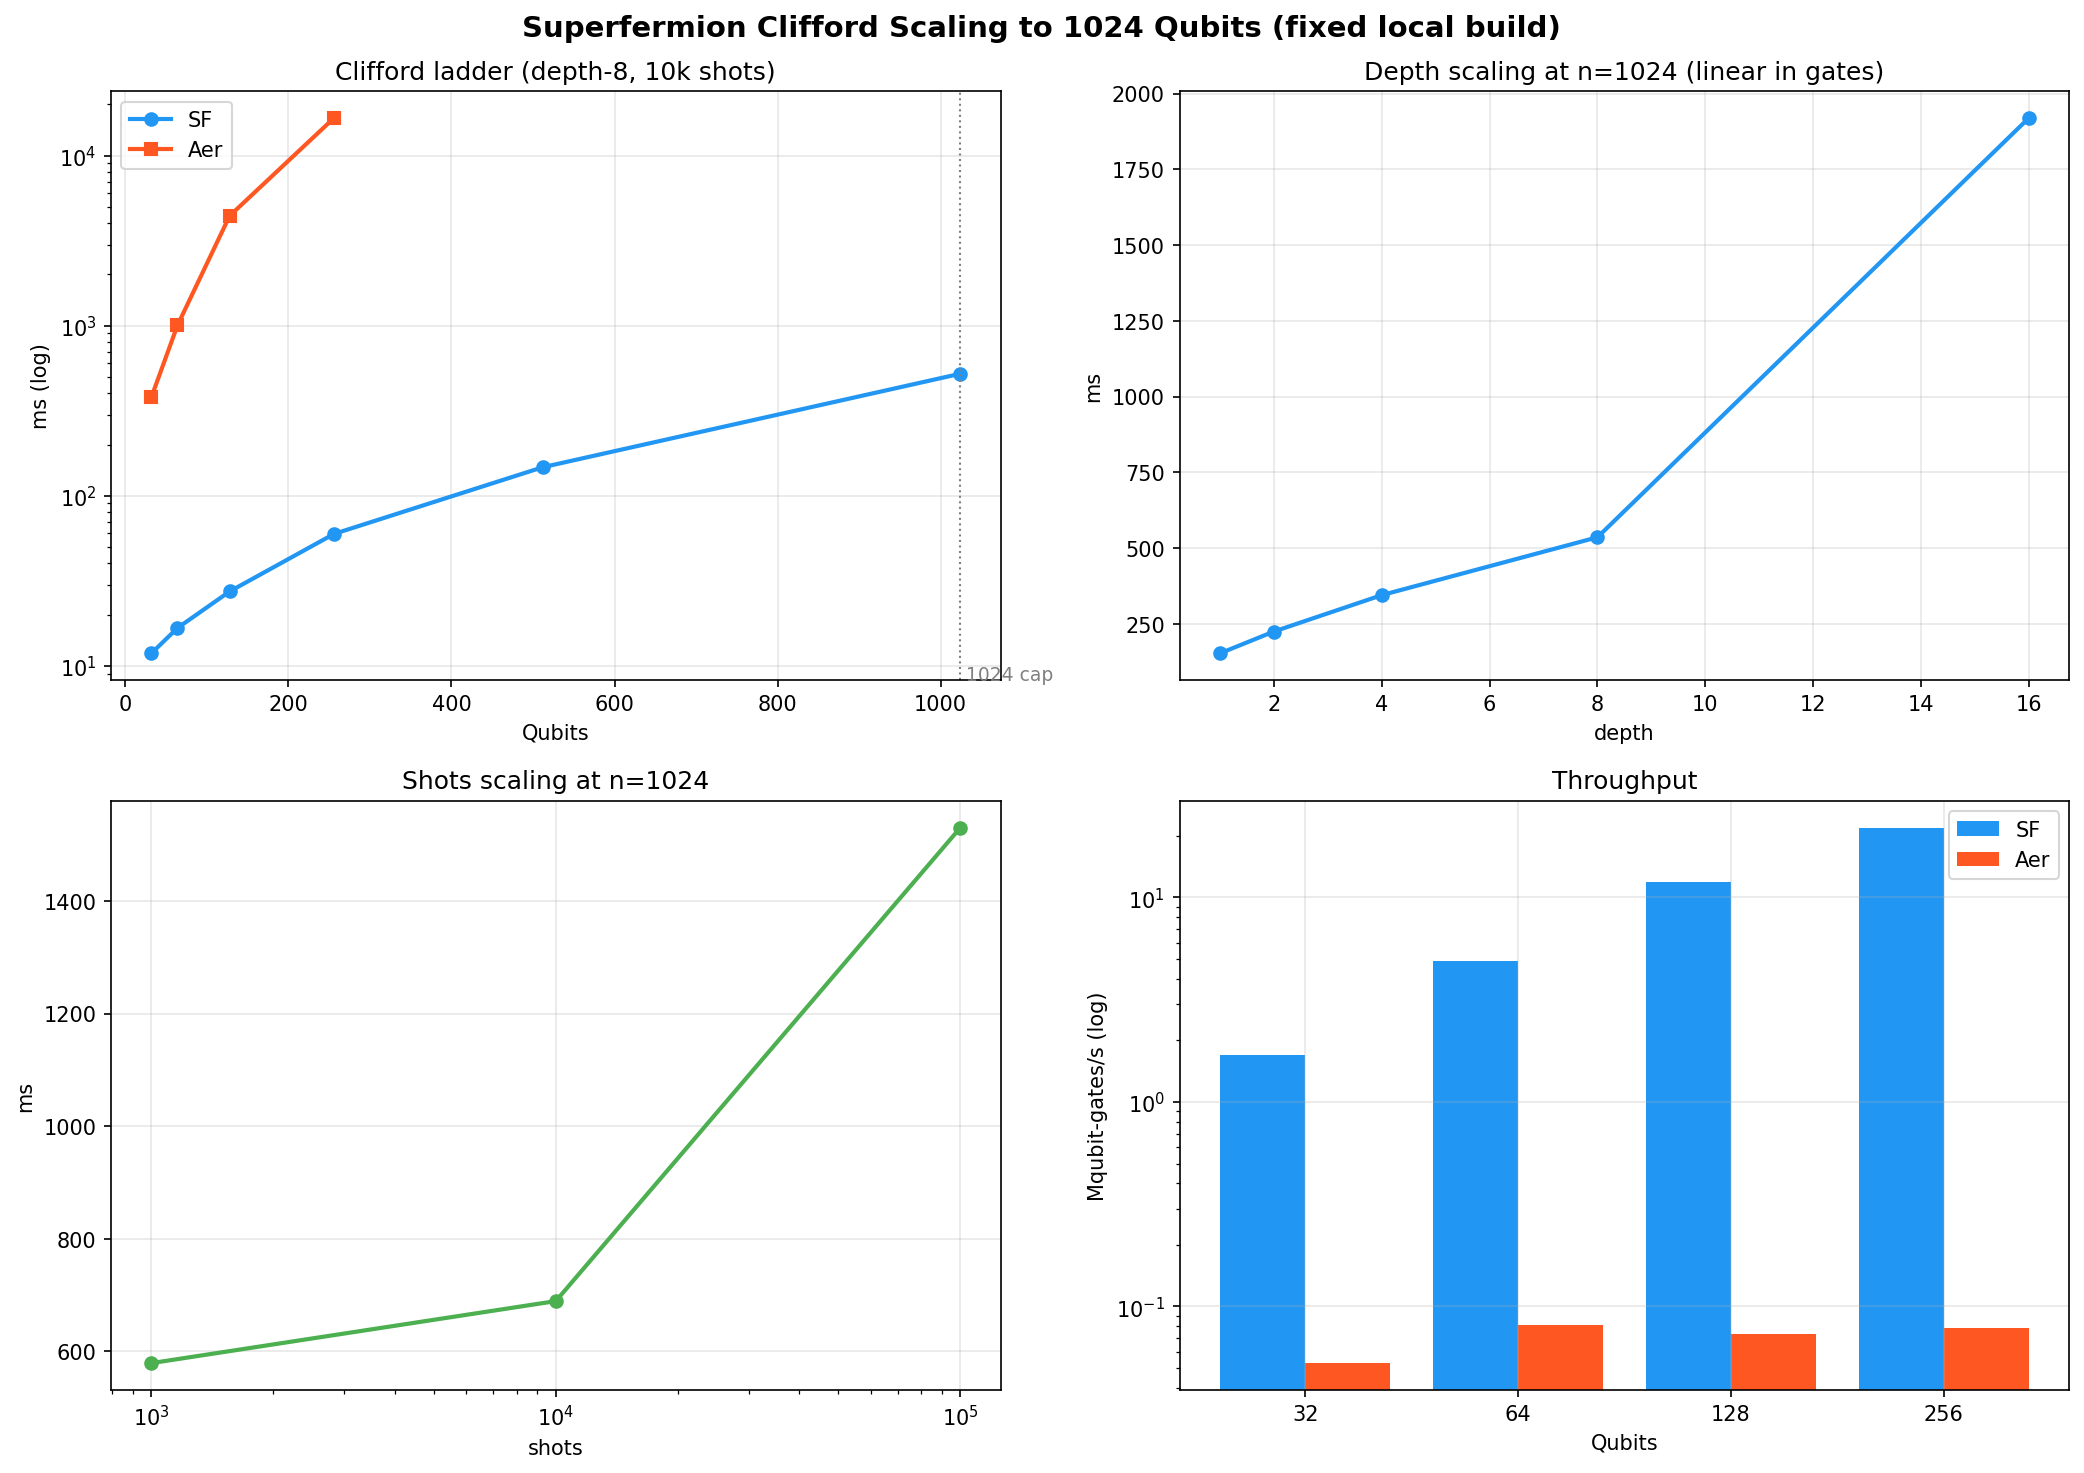

In [9]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Superfermion Clifford Scaling to 1024 Qubits (fixed local build)',
             fontsize=14, fontweight='bold')

ax = axes[0, 0]
ns = sorted(cliff_results)
ax.semilogy(ns, [cliff_results[n]['sf_ms'] for n in ns], 'o-', label='SF', color='#2196F3', lw=2)
ns_a = [n for n in ns if cliff_results[n]['qk_ms']]
ax.semilogy(ns_a, [cliff_results[n]['qk_ms'] for n in ns_a], 's-', label='Aer', color='#FF5722', lw=2)
ax.axvline(1024, color='gray', ls=':', lw=1)
ax.text(1024, ax.get_ylim()[0], ' 1024 cap', color='gray', fontsize=9)
ax.set_xlabel('Qubits'); ax.set_ylabel('ms (log)')
ax.set_title('Clifford ladder (depth-8, 10k shots)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ds = sorted(cap_depth_results)
ax.plot(ds, [cap_depth_results[d]['sf_ms'] for d in ds], 'o-', color='#2196F3', lw=2)
ax.set_xlabel('depth'); ax.set_ylabel('ms')
ax.set_title('Depth scaling at n=1024 (linear in gates)')
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
sh = sorted(cap_shot_results)
ax.plot(sh, [cap_shot_results[s]['sf_ms'] for s in sh], 'o-', color='#4CAF50', lw=2)
ax.set_xscale('log'); ax.set_xlabel('shots'); ax.set_ylabel('ms')
ax.set_title('Shots scaling at n=1024')
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
nst = [n for n in ns if throughput[n]['aer_qgs']]
x = np.arange(len(nst))
ax.bar(x - 0.2, [throughput[n]['sf_qgs']/1e6 for n in nst], 0.4, label='SF', color='#2196F3')
ax.bar(x + 0.2, [throughput[n]['aer_qgs']/1e6 for n in nst], 0.4, label='Aer', color='#FF5722')
ax.set_xticks(x); ax.set_xticklabels([str(n) for n in nst])
ax.set_yscale('log')
ax.set_xlabel('Qubits'); ax.set_ylabel('Mqubit-gates/s (log)')
ax.set_title('Throughput')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_clifford_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved benchmark_clifford_results.png')

from IPython.display import Image, display
display(Image('benchmark_clifford_results.png'))

In [10]:
summary = {
    'platform': {
        'engine_md5': _hashlib.md5(_core.read_bytes()).hexdigest().upper(),
        'python': platform.python_version(),
        'cpu': platform.processor() or 'unknown',
        'os': f'{platform.system()} {platform.release()}',
        'run_date': time.strftime('%Y-%m-%d %H:%M:%S'),
        'sf_version': sf.__version__,
    },
    'correctness': {k: v for k, v in correctness.items()},
    'ladder': {str(k): v for k, v in cliff_results.items()},
    'cap_depth': {str(k): v for k, v in cap_depth_results.items()},
    'cap_shots': {str(k): v for k, v in cap_shot_results.items()},
    'cap_behavior': cap_behavior,
    'throughput': {str(k): v for k, v in throughput.items()},
}
with open('benchmark_clifford_data.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print('Saved benchmark_clifford_data.json')
print(f'  engine md5 : {summary["platform"]["engine_md5"]}')

Saved benchmark_clifford_data.json
  engine md5 : 17B755C032D01D0C9711EA2B75751506


## Methodology Notes

- **What is measured**: raw simulation + sampling time on this host, single process,
  circuits built once outside the timed region (Aer's transpilation is part of its
  `run()` call and stays inside its timing, as it does for real users).
- **Where Aer stops**: Aer is a mature C++ stabilizer implementation, but its sampling
  path grows super-linearly here (52 s/call at n=500 measured on this build), so Aer
  rows end at n=256. Throughput up to 256 is the honest cross-engine comparison;
  512-1024 is SF-only with correctness gates against exact tableau math.
- **What is NOT measured**: distributed or multi-node simulation, non-Clifford
  workloads (see the statevector/MPS notebooks), and hardware.
- **Known limits**: the tableau cap is 1024 qubits (clean `ValueError` beyond it);
  large-N GHZ remains available via MPS, but generic high-entanglement Clifford
  circuits above 1024 qubits have no exact representation in the current build.